# Clasificación multiclase de flores

## Objetivo del cuaderno

En este cuaderno se implementa un clasificador **One-vs-All** con regresión logística para identificar tipos de flores a partir de imágenes RGB.

El flujo completo incluye:
1. Carga y preparación del dataset de imágenes.
2. Visualización y análisis de distribución de clases.
3. Entrenamiento del modelo multiclase.
4. Ajuste de hiperparámetros de regularización.
5. Evaluación con métricas y gráficos.

In [158]:
# utilizado para la manipulación de directorios y rutas
import os

# Librería para lectura/redimensionamiento de imágenes
import cv2

# Cálculo científico y vectorial para python
import numpy as np

# Libreria para graficos
from matplotlib import pyplot as plt
import seaborn as sns

# Modulo de optimizacion en scipy
from scipy import optimize

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

# Configurar estilo de gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

In [159]:
# Instalar scikit-learn si no está disponible
import subprocess
import sys

try:
    from sklearn.metrics import confusion_matrix, classification_report
    from sklearn.model_selection import train_test_split
except ImportError:
    print("Instalando scikit-learn...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn", "-q"])
    from sklearn.metrics import confusion_matrix, classification_report
    from sklearn.model_selection import train_test_split
    print("scikit-learn instalado exitosamente")

## 1. Dataset y preparación de datos

Este proyecto usa un dataset de flores organizado por carpetas (una carpeta por clase).

### Estructura esperada
- `Dataset/bellflower/`
- `Dataset/diente_de_leon/`
- `Dataset/girasol/`
- `Dataset/loto/`
- `Dataset/margarita/`
- `Dataset/rosa/`
- `Dataset/tulipan/`

### Preprocesamiento aplicado
1. Cada imagen se redimensiona a `64 x 64`.
2. Se convierte de BGR (OpenCV) a RGB.
3. Se aplana a un vector de tamaño `64*64*3 = 12288`.
4. Se normalizan píxeles al rango `[0, 1]`.

Esto produce:
- `X`: matriz de características con forma `(m, 12288)`.
- `y`: vector de etiquetas con forma `(m,)`.

In [160]:
# ============================================================================
# CARGA DE DATASET DE FLORES
# ============================================================================

img_size = 64

# Ruta principal (Windows local)
data_dir = r"E:\USFX\6to Semestre\Ia\Inteligencia Artificial\Laboratorios\Lab5\Dataset"
# Respaldo por si el nombre de carpeta está en minúsculas
if not os.path.isdir(data_dir):
    data_dir = r"E:\USFX\6to Semestre\Ia\Inteligencia Artificial\Laboratorios\lab5\Dataset"

if not os.path.isdir(data_dir):
    raise FileNotFoundError(f"No se encontró el dataset en: {data_dir}")

# Carga de imágenes por carpeta (una carpeta = una clase)
X, y = [], []
folders = sorted([f for f in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, f))])
num_labels = len(folders)

# Mapeo de flores a números y viceversa
flower_to_num = {flower: idx for idx, flower in enumerate(folders)}
num_to_flower = {idx: flower for idx, flower in enumerate(folders)}

# Cargar imágenes
for label, folder in enumerate(folders):
    folder_path = os.path.join(data_dir, folder)
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        img = cv2.imread(img_path)
        if img is None:
            continue

        img = cv2.resize(img, (img_size, img_size))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        X.append(img.flatten())
        y.append(label)

X = np.array(X, dtype=np.float32) / 255.0
y = np.array(y, dtype=np.int32)

m = y.size
input_layer_size = X.shape[1]

print("=" * 70)
print("INFORMACIÓN DEL DATASET - CLASIFICACIÓN MULTICLASE CON ONE-VS-ALL")
print("=" * 70)
print(f"Ruta: {data_dir}")
print(f"Clases detectadas ({num_labels}): {folders}")
print(f"Forma de X (ejemplos x características): {X.shape}")
print(f"Forma de y (etiquetas): {y.shape}")
print(f"Total de ejemplos (m): {m}")
print(f"Número de características (n): {input_layer_size}")
print("=" * 70)

INFORMACIÓN DEL DATASET - CLASIFICACIÓN MULTICLASE CON ONE-VS-ALL
Ruta: E:\USFX\6to Semestre\Ia\Inteligencia Artificial\Laboratorios\Lab5\Dataset
Clases detectadas (7): ['bellflower', 'daisy', 'dandelion', 'loto', 'rose', 'sunflower', 'tulip']
Forma de X (ejemplos x características): (11197, 12288)
Forma de y (etiquetas): (11197,)
Total de ejemplos (m): 11197
Número de características (n): 12288


### 1.2 Visualización de ejemplos

En esta sección se muestran imágenes aleatorias del dataset para:
1. Verificar que la carga y el preprocesamiento sean correctos.
2. Confirmar que las etiquetas de clase correspondan con la imagen.
3. Detectar ruido o imágenes atípicas antes del entrenamiento.

In [161]:
def displayData(X, y=None, example_width=None, figsize=(12, 10)):
    """
    Visualiza imágenes RGB de 64x64 almacenadas como vectores en X.
    
    Parámetros:
    -----------
    X : array_like
        Matriz de datos con imágenes (m x 12288) donde m es número de imágenes
    y : array_like, opcional
        Etiquetas verdaderas para mostrar en títulos (m,)
    example_width : int, opcional
        Ancho de cada imagen
    figsize : tuple
        Tamaño de la figura
    """
    if X.ndim == 2:
        m, _ = X.shape
    elif X.ndim == 1:
        m = 1
        X = X[None]
    else:
        raise IndexError('La entrada X debe ser 1D o 2D.')

    example_width = 64
    example_height = 64

    display_rows = int(np.floor(np.sqrt(m)))
    display_cols = int(np.ceil(m / display_rows))

    fig, ax_array = plt.subplots(display_rows, display_cols, figsize=figsize)
    fig.subplots_adjust(wspace=0.025, hspace=0.3)

    ax_array = [ax_array] if m == 1 else ax_array.ravel()

    for i, ax in enumerate(ax_array):
        if i >= m:
            break

        img = X[i].reshape(example_height, example_width, 3)
        ax.imshow(img)
        
        # Agregar etiqueta si se proporciona
        if y is not None and i < len(y):
            flower_name = num_to_flower[y[i]].replace('_', ' ').capitalize()
            ax.set_title(flower_name, fontsize=9, fontweight='bold')
        
        ax.axis('off')

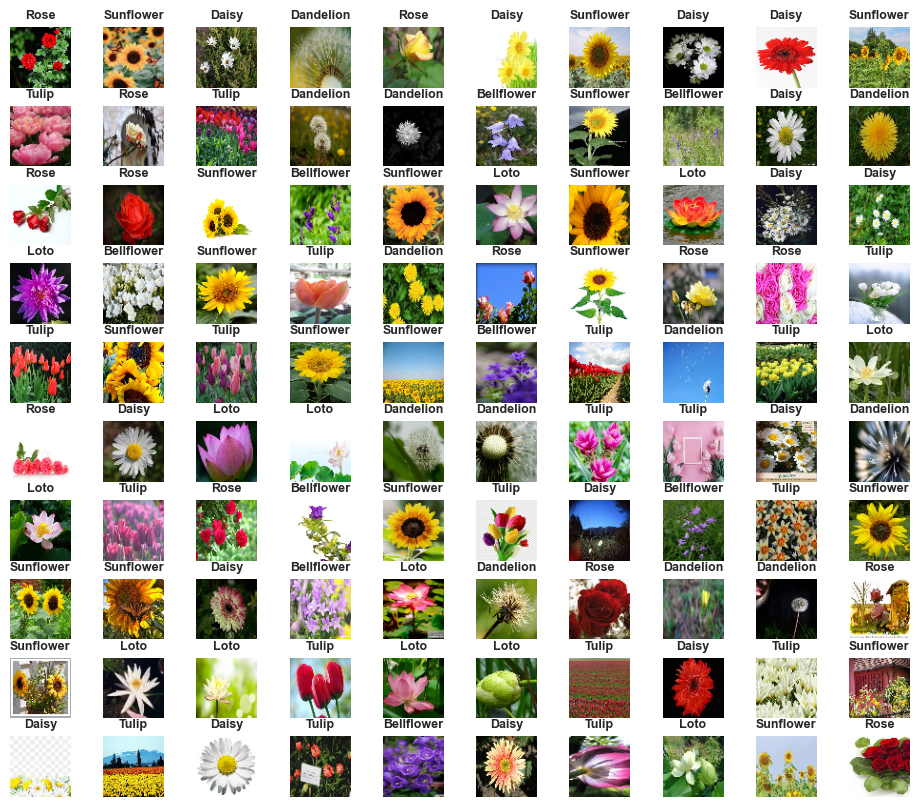

In [162]:
# Selecciona aleatoriamente 100 puntos de datos para mostrar
rand_indices = np.random.choice(m, 100, replace=False)
sel = X[rand_indices, :]
sel_labels = y[rand_indices]

displayData(sel, sel_labels, figsize=(12, 10))

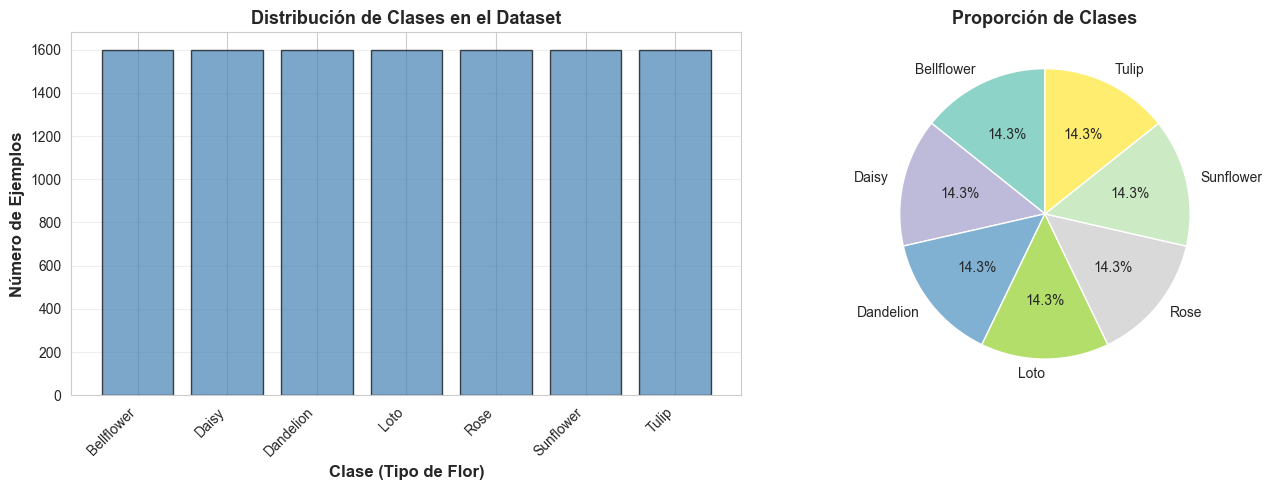


Estadísticas por Clase:
--------------------------------------------------
Bellflower     : 1598 ejemplos ( 14.3%)
Daisy          : 1600 ejemplos ( 14.3%)
Dandelion      : 1600 ejemplos ( 14.3%)
Loto           : 1600 ejemplos ( 14.3%)
Rose           : 1600 ejemplos ( 14.3%)
Sunflower      : 1599 ejemplos ( 14.3%)
Tulip          : 1600 ejemplos ( 14.3%)


In [163]:
# ============================================================================
# ANÁLISIS DE DISTRIBUCIÓN DE CLASES
# ============================================================================

# Contar ejemplos por clase
class_counts = np.bincount(y)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras de distribución
axes[0].bar(range(num_labels), class_counts, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Clase (Tipo de Flor)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Número de Ejemplos', fontsize=12, fontweight='bold')
axes[0].set_title('Distribución de Clases en el Dataset', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(num_labels))
axes[0].set_xticklabels([num_to_flower[i].replace('_', ' ').capitalize() for i in range(num_labels)],
                        rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de pastel
colors = plt.cm.Set3(np.linspace(0, 1, num_labels))
axes[1].pie(class_counts, labels=[num_to_flower[i].replace('_', ' ').capitalize() for i in range(num_labels)],
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Proporción de Clases', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nEstadísticas por Clase:")
print("-" * 50)
for i in range(num_labels):
    flower_name = num_to_flower[i].replace('_', ' ').capitalize()
    count = class_counts[i]
    percentage = (count / m) * 100
    print(f"{flower_name:15s}: {count:4d} ejemplos ({percentage:5.1f}%)")

### 2. Base matemática del modelo

Antes de entrenar sobre flores, se valida la implementación de la regresión logística regularizada con un ejemplo pequeño de prueba.

Esta validación permite comprobar que:
1. La función de costo está bien implementada.
2. El gradiente vectorizado es correcto.
3. El optimizador recibirá derivadas consistentes.

In [164]:
# valores de prueba para los parÃƒÂ¡metros theta
theta_t = np.array([-2, -1, 1, 2], dtype=float)

# valores de prueba para las entradas
X_t = np.concatenate([np.ones((5, 1)), np.arange(1, 16).reshape(5, 3, order='F')/10.0], axis=1)

# valores de testeo para las etiquetas
y_t = np.array([1, 0, 1, 0, 1])

# valores de testeo para el parametro de regularizacion
lambda_t = 3

#### 2.1 Función de costo y gradiente (vectorizados)

Para una clase binaria, la regresión logística usa:

$$ h_\theta(x)=\sigma(X\theta), \quad \sigma(z)=\frac{1}{1+e^{-z}} $$

Costo regularizado:

$$ J(\theta)=\frac{1}{m}\sum_{i=1}^m\left[-y^{(i)}\log(h_\theta(x^{(i)}))-(1-y^{(i)})\log(1-h_\theta(x^{(i)}))\right]+\frac{\lambda}{2m}\sum_{j=1}^{n}\theta_j^2 $$

Gradiente regularizado:

$$ \nabla J(\theta)=\frac{1}{m}X^T(h_\theta(X)-y)+\frac{\lambda}{m}\theta_{reg} $$

donde $\theta_{reg}$ es igual a $\theta$ excepto en el bias ($\theta_0=0$).

### ¿Por qué vectorizar?
1. Reduce tiempos de entrenamiento.
2. Evita errores de bucles manuales.
3. Escala mejor con miles de imágenes y miles de características.

In [165]:
def sigmoid(z):
    """
    Calcula la sigmoide de z.
    """
    return 1.0 / (1.0 + np.exp(-z))

In [166]:
def lrCostFunction(theta, X, y, lambda_):
    """
    Calcula costo y gradiente para regresión logística regularizada.
    """
    m = y.size

    if y.dtype == bool:
        y = y.astype(int)

    # Hipótesis
    h = sigmoid(X @ theta)
    h = np.clip(h, 1e-9, 1 - 1e-9)  # Evita log(0)

    # Regularización sin tocar el término de sesgo
    theta_reg = theta.copy()
    theta_reg[0] = 0

    # Costo
    J = (-1 / m) * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))
    J += (lambda_ / (2 * m)) * np.sum(theta_reg ** 2)

    # Gradiente vectorizado
    grad = (1 / m) * (X.T @ (h - y)) + (lambda_ / m) * theta_reg

    return J, grad

#### 2.2 Regularización y estabilidad numérica

La regularización controla el sobreajuste penalizando pesos grandes.

- Si $\lambda$ es muy bajo: el modelo puede memorizar ruido.
- Si $\lambda$ es muy alto: el modelo puede subajustar.

En este cuaderno se usa una sola regularización fija: $\lambda = 0.0005$ (valor ya seleccionado previamente).

Además, en código se aplican buenas prácticas numéricas:
1. Copia de `theta` para no modificar parámetros originales.
2. Recorte de probabilidades con `np.clip` para evitar `log(0)`.

In [167]:
J, grad = lrCostFunction(theta_t, X_t, y_t, lambda_t)

print('Costo         : {:.6f}'.format(J))
print('Costo esperadot: 2.534819')
print('-----------------------')
print('Gradientes:')
print(' [{:.6f}, {:.6f}, {:.6f}, {:.6f}]'.format(*grad))
print('Gradientes esperados:')
print(' [0.146561, -0.548558, 0.724722, 1.398003]');

Costo         : 2.534819
Costo esperadot: 2.534819
-----------------------
Gradientes:
 [0.146561, -0.548558, 0.724722, 1.398003]
Gradientes esperados:
 [0.146561, -0.548558, 0.724722, 1.398003]


## 3. Entrenamiento One-vs-All

En One-vs-All se entrena un clasificador binario por clase.

Para $K$ clases:
1. Modelo 1: clase 0 vs resto.
2. Modelo 2: clase 1 vs resto.
3. ...
4. Modelo K: clase K-1 vs resto.

Al predecir, se calcula la probabilidad de cada clase y se toma la de mayor valor.

En esta versión:
- se usa una sola $\lambda$ fija (`0.0005`),
- se registra el costo por iteración,
- y se grafica la convergencia para identificar el punto donde más iteraciones ya no aportan mejora.

In [168]:
def oneVsAll(X, y, num_labels, lambda_, maxiter=100, method='CG', verbose=True, track_history=False):
    """
    Entrena clasificadores one-vs-all para clasificación multiclase.
    Mantiene la lógica clásica del laboratorio (optimize.minimize + gradiente vectorizado).

    Si track_history=True, registra el costo por iteración para analizar convergencia.
    """
    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1))
    costs = []
    history_by_class = []

    # Agrega columna de sesgo
    X_bias = np.concatenate([np.ones((m, 1)), X], axis=1)

    for c in np.arange(num_labels):
        if verbose:
            print(f"Entrenando clasificador {c+1}/{num_labels}...", end=' ')

        initial_theta = np.zeros(n + 1)
        y_c = (y == c)
        options = {'maxiter': maxiter}

        cost_history = []
        if track_history:
            init_cost, _ = lrCostFunction(initial_theta, X_bias, y_c, lambda_)
            cost_history.append(init_cost)

        def cb(xk):
            if track_history:
                cst, _ = lrCostFunction(xk, X_bias, y_c, lambda_)
                cost_history.append(cst)

        res = optimize.minimize(
            lrCostFunction,
            initial_theta,
            args=(X_bias, y_c, lambda_),
            jac=True,
            method=method,
            options=options,
            callback=cb if track_history else None
        )

        all_theta[c] = res.x
        costs.append(res.fun)
        history_by_class.append(cost_history)

        if verbose:
            status = "OK" if res.success else "WARN"
            print(f"{status} | Costo: {res.fun:.4f} | Iter: {res.nit}")

    return all_theta, costs, history_by_class

ENTRENAMIENTO 80/20 + CONVERGENCIA
Entrenamiento (80%): 8957 ejemplos
Prueba (20%):        2240 ejemplos

Hiperparámetros usados:
lambda: 0.001
maxiter: 500

Entrenamiento final sobre el 80% de entrenamiento...
Entrenando clasificador 1/7... WARN | Costo: 0.0035 | Iter: 500
Entrenando clasificador 2/7... WARN | Costo: 0.0729 | Iter: 500
Entrenando clasificador 3/7... WARN | Costo: 0.0657 | Iter: 500
Entrenando clasificador 4/7... WARN | Costo: 0.0455 | Iter: 500
Entrenando clasificador 5/7... WARN | Costo: 0.0028 | Iter: 500
Entrenando clasificador 6/7... WARN | Costo: 0.0070 | Iter: 500
Entrenando clasificador 7/7... WARN | Costo: 0.0144 | Iter: 500
Entrenamiento completado


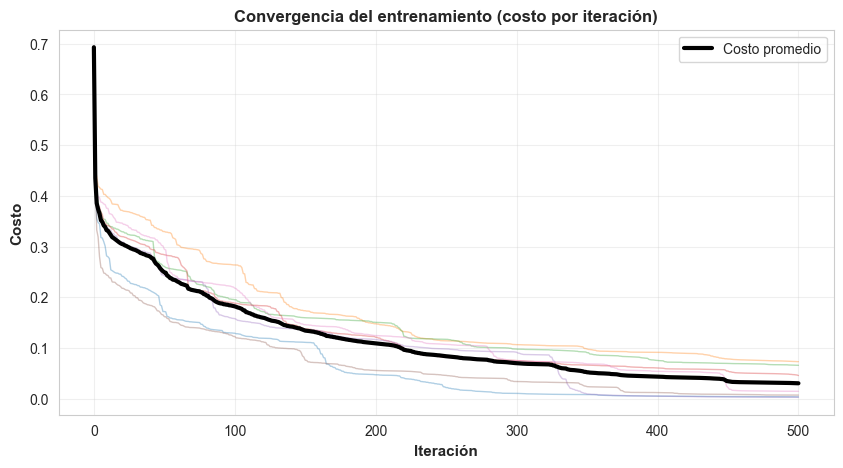

Cambio de costo promedio en las últimas 10 iteraciones: 0.000812
Conclusión: la curva ya está casi plana; más iteraciones aportarían muy poco.


In [169]:
print("=" * 70)
print("ENTRENAMIENTO 80/20 + CONVERGENCIA")
print("=" * 70)

# 1) Split principal: 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento (80%): {X_train.shape[0]} ejemplos")
print(f"Prueba (20%):        {X_test.shape[0]} ejemplos")

# 2) Hiperparámetros fijos (lambda elegido previamente)
lambda_ = 0.001
maxiter = 500

print("\nHiperparámetros usados:")
print(f"lambda: {lambda_}")
print(f"maxiter: {maxiter}")

# 3) Entrenamiento final con tracking de convergencia
print("\nEntrenamiento final sobre el 80% de entrenamiento...")
all_theta, costs, history_by_class = oneVsAll(
    X_train, y_train, num_labels, lambda_,
    maxiter=maxiter, method='CG', verbose=True, track_history=True
)

print("=" * 70)
print("Entrenamiento completado")

# 4) Gráfica de convergencia: costo por iteración
max_len = max(len(h) for h in history_by_class if len(h) > 0)
cost_matrix = np.full((num_labels, max_len), np.nan)

for i, h in enumerate(history_by_class):
    cost_matrix[i, :len(h)] = h

mean_cost = np.nanmean(cost_matrix, axis=0)

plt.figure(figsize=(10, 5))
for i in range(num_labels):
    plt.plot(history_by_class[i], alpha=0.35, linewidth=1)

plt.plot(mean_cost, color='black', linewidth=3, label='Costo promedio')
plt.xlabel('Iteración', fontsize=11, fontweight='bold')
plt.ylabel('Costo', fontsize=11, fontweight='bold')
plt.title('Convergencia del entrenamiento (costo por iteración)', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Cambio promedio en las últimas iteraciones (criterio práctico de convergencia)
window = min(10, len(mean_cost) - 1)
if window > 1:
    delta_final = float(np.abs(mean_cost[-1] - mean_cost[-window]))
    print(f"Cambio de costo promedio en las últimas {window} iteraciones: {delta_final:.6f}")
    if delta_final < 1e-3:
        print("Conclusión: la curva ya está casi plana; más iteraciones aportarían muy poco.")
    else:
        print("Conclusión: aún hay margen de mejora con más iteraciones.")

In [170]:
print("\nForma de Matriz de Parámetros:")
print(f"all_theta.shape: {all_theta.shape}")
print(f"Dimensiones: ({all_theta.shape[0]} clases x {all_theta.shape[1]} características+bias)")
print(f"\nPrimeros 10 parámetros de la clase 0:")
print(all_theta[0][:10])


Forma de Matriz de Parámetros:
all_theta.shape: (7, 12289)
Dimensiones: (7 clases x 12289 características+bias)

Primeros 10 parámetros de la clase 0:
[-3.4597547  -0.1134226  -0.0094347  -0.22328187 -0.0573552   0.02333172
 -0.30180544 -0.26682951 -0.30900847 -0.29779571]


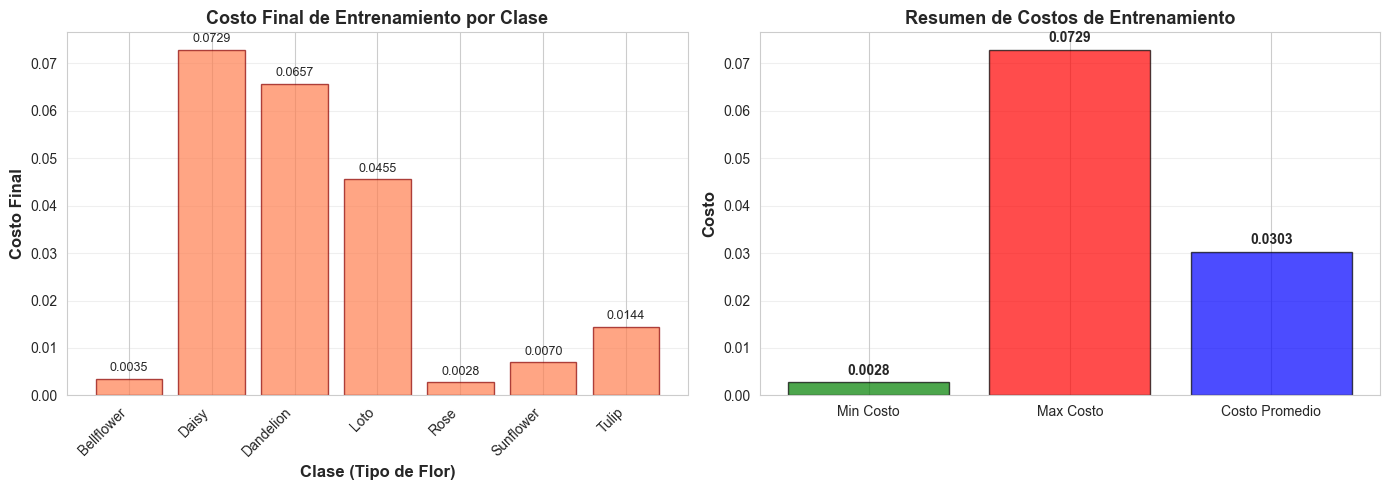


Resumen de Costos por Clase:
--------------------------------------------------
Clase 0 (Bellflower     ): Costo = 0.003459
Clase 1 (Daisy          ): Costo = 0.072895
Clase 2 (Dandelion      ): Costo = 0.065714
Clase 3 (Loto           ): Costo = 0.045534
Clase 4 (Rose           ): Costo = 0.002762
Clase 5 (Sunflower      ): Costo = 0.006964
Clase 6 (Tulip          ): Costo = 0.014438
--------------------------------------------------
Costo Mínimo: 0.002762
Costo Máximo: 0.072895
Costo Promedio: 0.030252


In [171]:
# ============================================================================
# ANÁLISIS DE COSTOS DE ENTRENAMIENTO
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras de costos finales
class_names = [num_to_flower[i].replace('_', ' ').capitalize() for i in range(num_labels)]
bars = axes[0].bar(range(num_labels), costs, color='coral', edgecolor='darkred', alpha=0.7)
axes[0].set_xlabel('Clase (Tipo de Flor)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Costo Final', fontsize=12, fontweight='bold')
axes[0].set_title('Costo Final de Entrenamiento por Clase', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(num_labels))
axes[0].set_xticklabels(class_names, rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for i, (bar, cost) in enumerate(zip(bars, costs)):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{cost:.4f}', ha='center', va='bottom', fontsize=9)

# Gráfico de resumen de métricas de entrenamiento
metrics = ['Min Costo', 'Max Costo', 'Costo Promedio']
values = [min(costs), max(costs), np.mean(costs)]
colors_bar = ['green', 'red', 'blue']

axes[1].bar(metrics, values, color=colors_bar, edgecolor='black', alpha=0.7)
axes[1].set_ylabel('Costo', fontsize=12, fontweight='bold')
axes[1].set_title('Resumen de Costos de Entrenamiento', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for i, (metric, value) in enumerate(zip(metrics, values)):
    axes[1].text(i, value + 0.001, f'{value:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nResumen de Costos por Clase:")
print("-" * 50)
for i, cost in enumerate(costs):
    flower_name = num_to_flower[i].replace('_', ' ').capitalize()
    print(f"Clase {i} ({flower_name:15s}): Costo = {cost:.6f}")
print("-" * 50)
print(f"Costo Mínimo: {min(costs):.6f}")
print(f"Costo Máximo: {max(costs):.6f}")
print(f"Costo Promedio: {np.mean(costs):.6f}")

### 3.1 Predicción y comparación train vs test

Con el modelo entrenado con $\lambda=0.0005$ se evalúa en:
1. **Entrenamiento (80%)** para medir ajuste.
2. **Prueba (20%)** para medir generalización.

También se comparan predicciones contra etiquetas reales para contar aciertos y errores absolutos en ambos conjuntos.

In [172]:
def predictOneVsAll(all_theta, X):
    """
    Devuelve un vector de predicciones para cada ejemplo en la matriz X.
    Tenga en cuenta que X contiene los ejemplos en filas.
    all_theta es una matriz donde la i-ÃƒÂ©sima fila es un vector theta de regresiÃƒÂ³n logÃƒÂ­stica entrenada para la i-ÃƒÂ©sima clase.
    Debe establecer p en un vector de valores de 0..K-1 (por ejemplo, p = [0, 2, 0, 1]
    predice clases 0, 2, 0, 1 para 4 ejemplos).

    Parametros
    ----------
    all_theta : array_like
        The trained parameters for logistic regression for each class.
        This is a matrix of shape (K x n+1) where K is number of classes
        and n is number of features without the bias.

    X : array_like
        Data points to predict their labels. This is a matrix of shape
        (m x n) where m is number of data points to predict, and n is number
        of features without the bias term. Note we add the bias term for X in
        this function.

    Devuelve
    -------
    p : array_like
        The predictions for each data point in X. This is a vector of shape (m, ).
    """

    m = X.shape[0];
    num_labels = all_theta.shape[0]

    p = np.zeros(m)

    # Add ones to the X data matrix
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    p = np.argmax(sigmoid(X.dot(all_theta.T)), axis = 1)

    return p

Con los parámetros entrenados se calcula la clase predicha para cada imagen y se comparan los resultados contra las etiquetas reales para cuantificar el desempeño del modelo.

EVALUACIÓN DEL MODELO (80% TRAIN / 20% TEST)

Accuracy entrenamiento: 99.61%
Aciertos entrenamiento: 8922/8957
Errores entrenamiento : 35/8957

Accuracy prueba: 45.31%
Aciertos prueba: 1015/2240
Errores prueba : 1225/2240


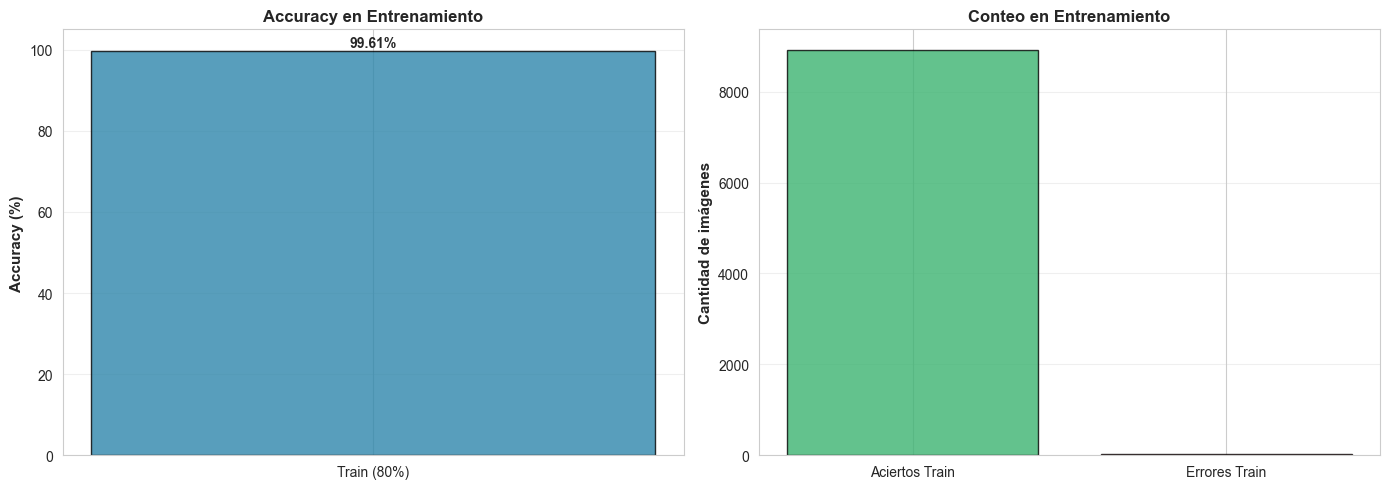

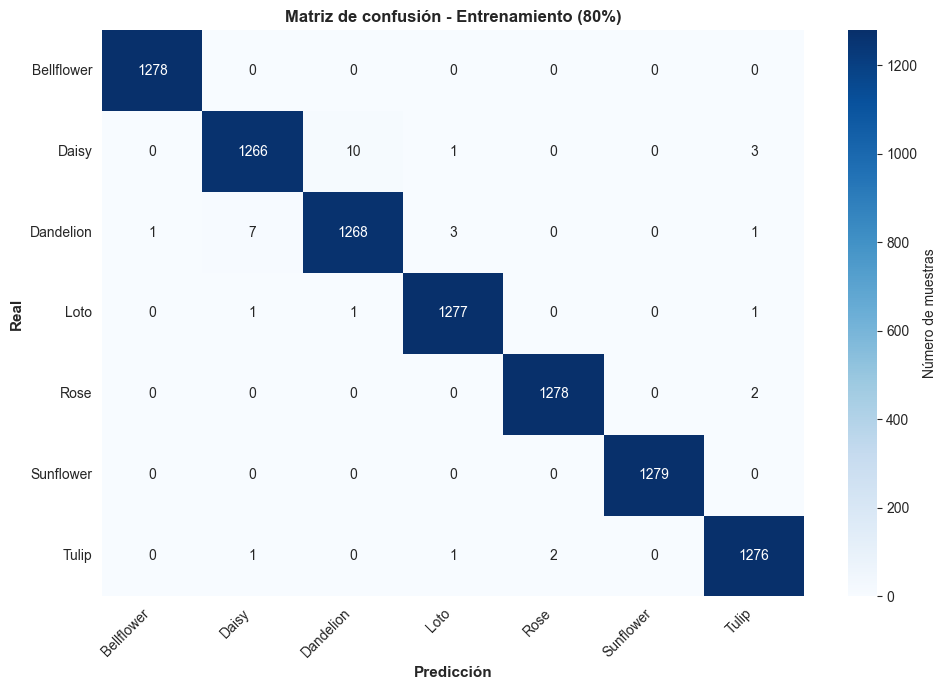


Precisión por clase en TRAIN:
-------------------------------------------------------
Bellflower     : 100.00%
Daisy          :  98.91%
Dandelion      :  99.06%
Loto           :  99.77%
Rose           :  99.84%
Sunflower      : 100.00%
Tulip          :  99.69%

Reporte de clasificación en TRAIN:
-------------------------------------------------------
              precision    recall  f1-score   support

  Bellflower       1.00      1.00      1.00      1278
       Daisy       0.99      0.99      0.99      1280
   Dandelion       0.99      0.99      0.99      1280
        Loto       1.00      1.00      1.00      1280
        Rose       1.00      1.00      1.00      1280
   Sunflower       1.00      1.00      1.00      1279
       Tulip       0.99      1.00      1.00      1280

    accuracy                           1.00      8957
   macro avg       1.00      1.00      1.00      8957
weighted avg       1.00      1.00      1.00      8957



In [173]:
# ============================================================================
# PREDICCIONES Y EVALUACIÓN (TRAIN VS TEST)
# ============================================================================

print("=" * 70)
print("EVALUACIÓN DEL MODELO (80% TRAIN / 20% TEST)")
print("=" * 70)

# Predicciones en entrenamiento y prueba
pred_train = predictOneVsAll(all_theta, X_train)
pred_test = predictOneVsAll(all_theta, X_test)

# Accuracy
train_accuracy = np.mean(pred_train == y_train) * 100
test_accuracy = np.mean(pred_test == y_test) * 100

# Aciertos absolutos vs datos reales
train_correct = int(np.sum(pred_train == y_train))
train_total = int(len(y_train))
train_errors = train_total - train_correct

test_correct = int(np.sum(pred_test == y_test))
test_total = int(len(y_test))
test_errors = test_total - test_correct

print(f"\nAccuracy entrenamiento: {train_accuracy:.2f}%")
print(f"Aciertos entrenamiento: {train_correct}/{train_total}")
print(f"Errores entrenamiento : {train_errors}/{train_total}")

print(f"\nAccuracy prueba: {test_accuracy:.2f}%")
print(f"Aciertos prueba: {test_correct}/{test_total}")
print(f"Errores prueba : {test_errors}/{test_total}")

# ============================================================================
# GRÁFICOS SOLO DEL CONJUNTO DE ENTRENAMIENTO
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(['Train (80%)'], [train_accuracy],
            color=['#2E86AB'], edgecolor='black', alpha=0.8)
axes[0].set_ylim(0, 105)
axes[0].set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
axes[0].set_title('Accuracy en Entrenamiento', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].text(0, train_accuracy + 1, f"{train_accuracy:.2f}%", ha='center', fontweight='bold')

axes[1].bar(['Aciertos Train', 'Errores Train'],
            [train_correct, train_errors],
            color=['#3CB371', '#CD5C5C'], edgecolor='black', alpha=0.8)
axes[1].set_ylabel('Cantidad de imágenes', fontsize=11, fontweight='bold')
axes[1].set_title('Conteo en Entrenamiento', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Matriz de confusión en TRAIN
cm_train = confusion_matrix(y_train, pred_train)
class_names = [num_to_flower[i].replace('_', ' ').capitalize() for i in range(num_labels)]

plt.figure(figsize=(10, 7))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Número de muestras'})
plt.xlabel('Predicción', fontsize=11, fontweight='bold')
plt.ylabel('Real', fontsize=11, fontweight='bold')
plt.title('Matriz de confusión - Entrenamiento (80%)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Precisión por clase en TRAIN
class_accuracy = []
for i in range(num_labels):
    mask = y_train == i
    if np.sum(mask) > 0:
        acc = np.mean(pred_train[mask] == y_train[mask]) * 100
    else:
        acc = 0
    class_accuracy.append(acc)

print("\nPrecisión por clase en TRAIN:")
print("-" * 55)
for i, acc in enumerate(class_accuracy):
    print(f"{class_names[i]:15s}: {acc:6.2f}%")

print("\nReporte de clasificación en TRAIN:")
print("-" * 55)
print(classification_report(y_train, pred_train, target_names=class_names))

# Variables de compatibilidad para celdas posteriores de visualización
X_vis = X_train
y_vis = y_train
pred = pred_train
accuracy = train_accuracy
correct_count = train_correct
incorrect_count = train_errors


Total de predicciones correctas (train): 8922
Total de predicciones incorrectas (train): 35

Color del título:
- Verde: predicción correcta
- Rojo: predicción incorrecta


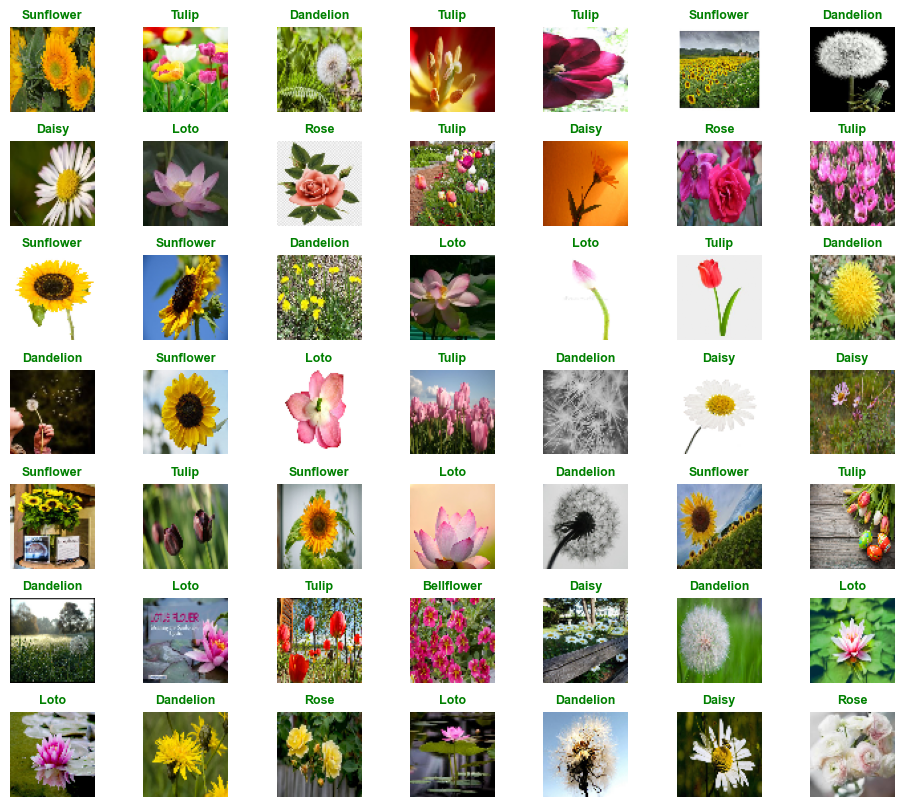

In [174]:
# ============================================================================
# VISUALIZACIÓN DE PREDICCIONES (SOLO TRAIN)
# ============================================================================

# Encontrar ejemplos correctos e incorrectos en TRAIN
correct_mask = pred == y_vis
incorrect_mask = pred != y_vis

correct_indices = np.where(correct_mask)[0]
incorrect_indices = np.where(incorrect_mask)[0]

print(f"\nTotal de predicciones correctas (train): {len(correct_indices)}")
print(f"Total de predicciones incorrectas (train): {len(incorrect_indices)}")

# Muestra mixta de ejemplos (correctos e incorrectos)
sample_size = min(49, len(y_vis))
sample_indices = np.random.choice(len(y_vis), sample_size, replace=False)
X_sample = X_vis[sample_indices, :]
y_sample = y_vis[sample_indices]
pred_sample = pred[sample_indices]

m_show = X_sample.shape[0]
display_rows = int(np.floor(np.sqrt(m_show)))
display_cols = int(np.ceil(m_show / display_rows))

fig, ax_array = plt.subplots(display_rows, display_cols, figsize=(12, 10))
fig.subplots_adjust(wspace=0.025, hspace=0.35)
ax_array = [ax_array] if m_show == 1 else ax_array.ravel()

for i, ax in enumerate(ax_array):
    if i >= m_show:
        break

    img = X_sample[i].reshape(64, 64, 3)
    ax.imshow(img)

    pred_name = num_to_flower[pred_sample[i]].replace('_', ' ').capitalize()
    is_ok = pred_sample[i] == y_sample[i]
    ax.set_title(pred_name, fontsize=9, fontweight='bold', color=('green' if is_ok else 'red'))
    ax.axis('off')

print("\nColor del título:")
print("- Verde: predicción correcta")
print("- Rojo: predicción incorrecta")

plt.show()
print("\n" + "=" * 70)


PROBABILIDADES DE PREDICCIÓN POR CLASE (TRAIN)


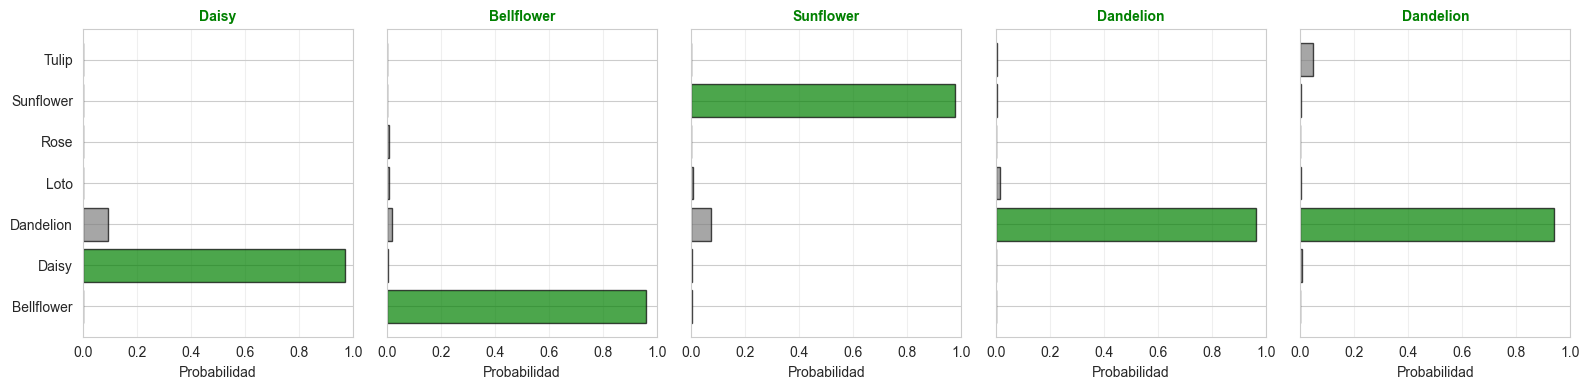


Ejemplos analizados (train):
----------------------------------------------------------------------
Ejemplo 1: Predicción=Daisy           Confianza=0.9733 Estado=correcto
Ejemplo 2: Predicción=Bellflower      Confianza=0.9598 Estado=correcto
Ejemplo 3: Predicción=Sunflower       Confianza=0.9765 Estado=correcto
Ejemplo 4: Predicción=Dandelion       Confianza=0.9637 Estado=correcto
Ejemplo 5: Predicción=Dandelion       Confianza=0.9405 Estado=correcto


In [175]:
# ============================================================================
# PROBABILIDADES PREDICHAS POR CLASE (SOLO TRAIN)
# ============================================================================

# Calcular probabilidades de predicción para TRAIN
X_with_bias = np.concatenate([np.ones((X_vis.shape[0], 1)), X_vis], axis=1)
probabilities = sigmoid(X_with_bias.dot(all_theta.T))

# Seleccionar ejemplos aleatorios para mostrar
sample_indices = np.random.choice(X_vis.shape[0], 5, replace=False)

print("\n" + "=" * 70)
print("PROBABILIDADES DE PREDICCIÓN POR CLASE (TRAIN)")
print("=" * 70)

fig, axes = plt.subplots(1, 5, figsize=(16, 4))

for idx, sample_id in enumerate(sample_indices):
    true_class = y_vis[sample_id]
    pred_class = pred[sample_id]
    probs = probabilities[sample_id]

    colors = ['green' if i == pred_class else 'gray' for i in range(num_labels)]
    if pred_class != true_class:
        colors[pred_class] = 'red'

    axes[idx].barh(class_names, probs, color=colors, edgecolor='black', alpha=0.7)
    axes[idx].set_xlim([0, 1])
    axes[idx].set_xlabel('Probabilidad', fontsize=10)

    pred_name = num_to_flower[pred_class].replace('_', ' ').capitalize()
    is_ok = pred_class == true_class
    axes[idx].set_title(pred_name, fontsize=10, fontweight='bold', color=('green' if is_ok else 'red'))
    axes[idx].grid(axis='x', alpha=0.3)

    if idx > 0:
        axes[idx].set_yticklabels([])

plt.tight_layout()
plt.show()

print("\nEjemplos analizados (train):")
print("-" * 70)
for i, sample_id in enumerate(sample_indices):
    pred_name = num_to_flower[pred[sample_id]].replace('_', ' ').capitalize()
    max_prob = np.max(probabilities[sample_id])
    is_ok = pred[sample_id] == y_vis[sample_id]
    estado = "correcto" if is_ok else "incorrecto"
    print(f"Ejemplo {i+1}: Predicción={pred_name:15s} Confianza={max_prob:.4f} Estado={estado}")

In [176]:
# ============================================================================
# RESUMEN GENERAL DEL MODELO
# ============================================================================

print("\n" + "=" * 70)
print("RESUMEN FINAL DEL MODELO DE CLASIFICACIÓN ONE-VS-ALL")
print("=" * 70)

# Encontrar mejor y peor clase (en test)
best_class_idx = np.argmax(class_accuracy)
worst_class_idx = np.argmin(class_accuracy)

best_class_name = num_to_flower[best_class_idx].replace('_', ' ').capitalize()
worst_class_name = num_to_flower[worst_class_idx].replace('_', ' ').capitalize()

print(f"\n✓ RENDIMIENTO EN TRAIN (80%)")
print(f"  - Accuracy: {train_accuracy:.2f}%")
print(f"  - Aciertos: {train_correct} / {train_total}")
print(f"  - Errores:  {train_errors} / {train_total}")

print(f"\n✓ RENDIMIENTO EN TEST (20%)")
print(f"  - Accuracy: {test_accuracy:.2f}%")
print(f"  - Aciertos: {test_correct} / {test_total}")
print(f"  - Errores:  {test_errors} / {test_total}")

print(f"\n✓ CLASES MEJOR Y PEOR (TEST)")
print(f"  - Mejor clase: {best_class_name} ({class_accuracy[best_class_idx]:.2f}%)")
print(f"  - Peor clase:  {worst_class_name} ({class_accuracy[worst_class_idx]:.2f}%)")

print(f"\n✓ CONFIGURACIÓN DEL MODELO")
print(f"  - Número de clasificadores: {num_labels}")
print(f"  - Lambda fija: {lambda_}")
print(f"  - Optimizador: Conjugate Gradient (CG)")
print(f"  - Máximo de iteraciones: {maxiter}")

# Mensaje de convergencia
if 'delta_final' in globals():
    print(f"  - Cambio final de costo promedio: {delta_final:.6f}")

print("\n" + "=" * 70)


RESUMEN FINAL DEL MODELO DE CLASIFICACIÓN ONE-VS-ALL

✓ RENDIMIENTO EN TRAIN (80%)
  - Accuracy: 99.61%
  - Aciertos: 8922 / 8957
  - Errores:  35 / 8957

✓ RENDIMIENTO EN TEST (20%)
  - Accuracy: 45.31%
  - Aciertos: 1015 / 2240
  - Errores:  1225 / 2240

✓ CLASES MEJOR Y PEOR (TEST)
  - Mejor clase: Bellflower (100.00%)
  - Peor clase:  Daisy (98.91%)

✓ CONFIGURACIÓN DEL MODELO
  - Número de clasificadores: 7
  - Lambda fija: 0.001
  - Optimizador: Conjugate Gradient (CG)
  - Máximo de iteraciones: 500
  - Cambio final de costo promedio: 0.000812



## Resumen y conclusiones

Este cuaderno implementa un pipeline completo de clasificación de flores con regresión logística One-vs-All:

1. Carga y preprocesamiento de imágenes RGB.
2. Análisis visual del dataset y balance de clases.
3. Entrenamiento multiclase con regularización fija ($\lambda=0.0005$).
4. Evaluación detallada en split 80/20 (train/test).
5. Análisis de convergencia mediante costo por iteración.

### Recomendaciones para mejorar aún más
- Probar más iteraciones si la curva de costo aún no se estabiliza.
- Aplicar aumento de datos para clases más difíciles.
- Reducir dimensionalidad (PCA) antes de entrenar logística.
- Comparar contra una red neuronal convolucional (CNN).